In [26]:
import scanpy as sc

In [12]:
!mkdir -p models/

In [15]:
%%bash

curl -L -o models/model_v1.1.tar.gz https://zenodo.org/records/10685499/files/model_v1.1.tar.gz?download=1

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
Task exception was never retrieved
future: <Task finished name='Task-16' coro=<ScriptMagics.shebang.<locals>._handle_stream() done, defined at /opt/homebrew/Caskroom/miniconda/base/envs/scimilarity/lib/python3.8/site-packages/IPython/core/magics/script.py:211> exception=ValueError('Separator is not found, and chunk exceed the limit')>
Traceback (most recent call last):
  File "/opt/homebrew/Caskroom/miniconda/base/envs/scimilarity/lib/python3.8/asyncio/streams.py", line 540, in readline
    line = await self.readuntil(sep)
  File "/opt/homebrew/Caskroom/miniconda/base/envs/scimilarity/lib/python3.8/asyncio/streams.py", line 618, in readuntil
    raise exceptions.LimitOverrunError(
asyncio.exceptions.LimitOverrunError: Separator is not found, and chunk exceed the limit

During handling of the above exception, another exception occu

In [24]:
%%bash

mkdir -p data/
curl -L -o "data/GSE136831_subsample.h5ad" \
   https://zenodo.org/records/13685881/files/GSE136831_subsample.h5ad?download=1

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 2099M  100 2099M    0     0  3901k      0  0:09:11  0:09:11 --:--:-- 27.4M


In [28]:
data_path = "data/GSE136831_subsample.h5ad"

In [17]:
!tar xvfz models/model_v1.1.tar.gz

x model_v1.1/
x model_v1.1/cellsearch/
x model_v1.1/cellsearch/cell_embedding/
x model_v1.1/cellsearch/cell_embedding/__fragment_meta/
x model_v1.1/cellsearch/cell_embedding/__fragments/
x model_v1.1/cellsearch/cell_embedding/__fragments/__1704414576446_1704414676106_45769c61e7fe48f486dbecf618b9dad7_16/
x model_v1.1/cellsearch/cell_embedding/__fragments/__1704414576446_1704414676106_45769c61e7fe48f486dbecf618b9dad7_16/__fragment_metadata.tdb
x model_v1.1/cellsearch/cell_embedding/__fragments/__1704414576446_1704414676106_45769c61e7fe48f486dbecf618b9dad7_16/a0.tdb
x model_v1.1/cellsearch/cell_embedding/__schema/
x model_v1.1/cellsearch/cell_embedding/__schema/__1704414562799_1704414562799_dfa31c9cd9f240c789d8cea2638408de
x model_v1.1/cellsearch/cell_embedding/__commits/
x model_v1.1/cellsearch/cell_embedding/__commits/__1704414576446_1704414676106_45769c61e7fe48f486dbecf618b9dad7_16.wrt
x model_v1.1/cellsearch/cell_embedding/__meta/
x model_v1.1/cellsearch/cell_metadata/
x model_v1.1/ce

In [18]:
from scimilarity.utils import lognorm_counts, align_dataset
from scimilarity import CellAnnotation

In [22]:
model_path = "model_v1.1"
ca = CellAnnotation(model_path=model_path)

In [29]:
adams = sc.read(data_path)

In [31]:
adams = align_dataset(adams, ca.gene_order)

In [32]:
adams = lognorm_counts(adams)

In [33]:
adams.obsm["X_scimilarity"] = ca.get_embeddings(adams.X)

In [34]:
sc.pp.neighbors(adams, use_rep="X_scimilarity")
sc.tl.umap(adams)

/opt/homebrew/Caskroom/miniconda/base/envs/scimilarity/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


/opt/homebrew/Caskroom/miniconda/base/envs/scimilarity/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


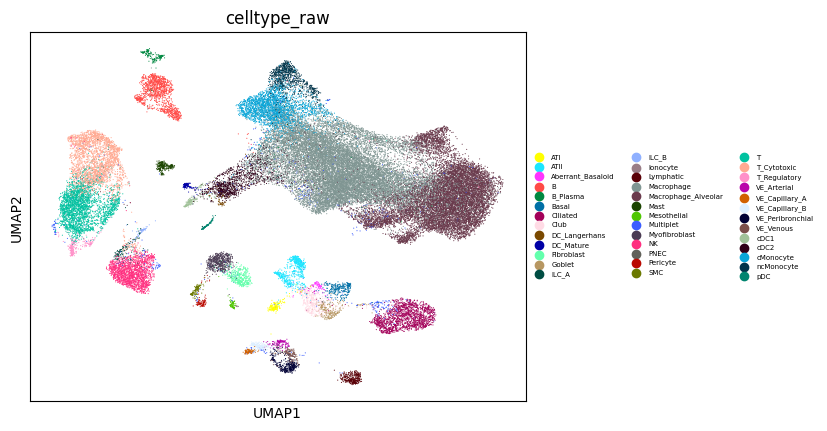

In [35]:
sc.pl.umap(adams, 
           color="celltype_raw", legend_fontsize=5)

In [36]:
predictions, nn_idxs, nn_dists, nn_stats = ca.get_predictions_knn(
    adams.obsm["X_scimilarity"]
)
adams.obs["predictions_unconstrained"] = predictions.values

Get nearest neighbors finished in: 0.1436488151550293 min


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50000/50000 [00:06<00:00, 7228.69it/s]


/opt/homebrew/Caskroom/miniconda/base/envs/scimilarity/lib/python3.8/site-packages/anndata/_core/anndata.py:1230: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/opt/homebrew/Caskroom/miniconda/base/envs/scimilarity/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


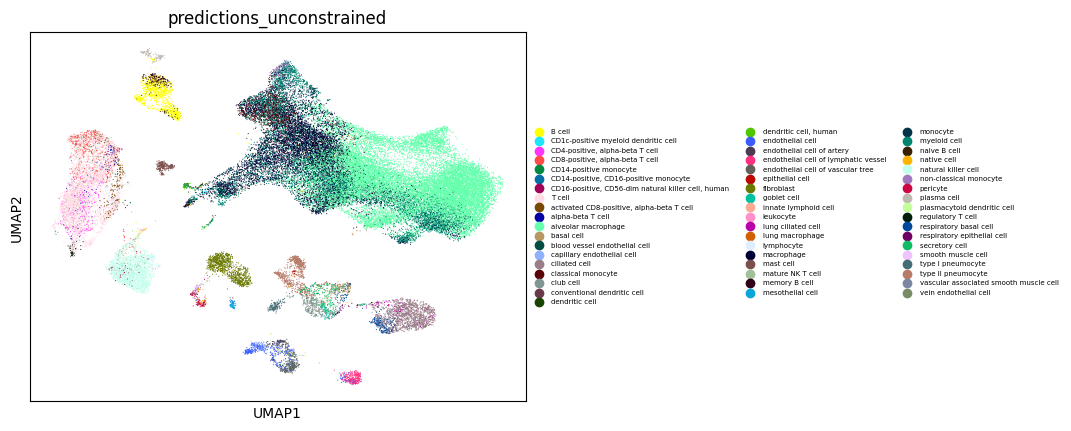

In [37]:
celltype_counts = adams.obs.predictions_unconstrained.value_counts()
well_represented_celltypes = celltype_counts[celltype_counts > 20].index

sc.pl.umap(
    adams[adams.obs.predictions_unconstrained.isin(well_represented_celltypes)],
    color="predictions_unconstrained",
    legend_fontsize=5,
)

In [38]:
target_celltypes = [
    "macrophage",
    "lung macrophage",
    "alveolar macrophage",
    "classical monocyte",
    "non-classical monocyte",
    "conventional dendritic cell",
    "plasmacytoid dendritic cell",
    "mast cell",
    "CD4-positive, alpha-beta T cell",
    "regulatory T cell",
    "CD8-positive, alpha-beta T cell",
    "mature NK T cell",
    "natural killer cell",
    "B cell",
    "plasma cell",
    "type I pneumocyte",
    "type II pneumocyte",
    "club cell",
    "goblet cell",
    "ciliated cell",
    "lung ciliated cell",
    "basal cell",
    "respiratory basal cell",
    "secretory cell",
    "neuroendocrine cell",
    "pulmonary ionocyte",
    "endothelial cell of vascular tree",
    "endothelial cell of lymphatic vessel",
    "pericyte",
    "smooth muscle cell",
    "vascular associated smooth muscle cell",
    "fibroblast",
    "myofibroblast cell",
]

ca.safelist_celltypes(target_celltypes)

In [39]:
adams = ca.annotate_dataset(adams)

Get nearest neighbors finished in: 0.08341571887334188 min


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50000/50000 [00:06<00:00, 8298.38it/s]


/opt/homebrew/Caskroom/miniconda/base/envs/scimilarity/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


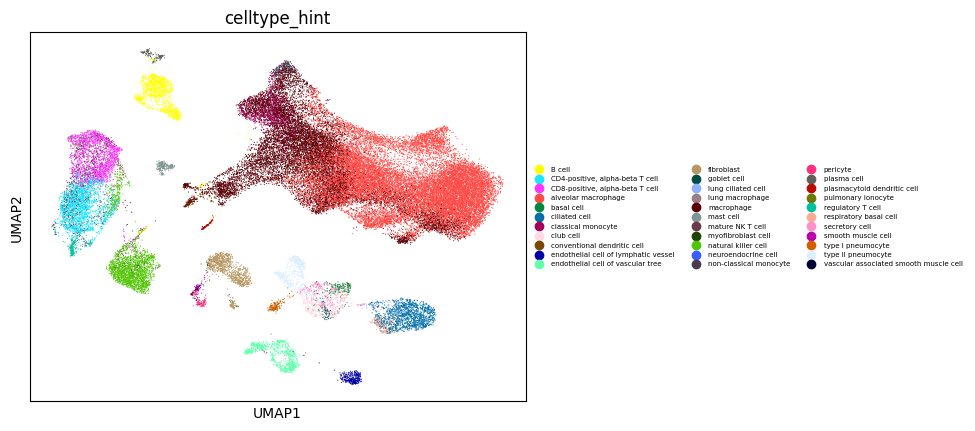

In [40]:
sc.pl.umap(adams, color="celltype_hint", legend_fontsize=5)

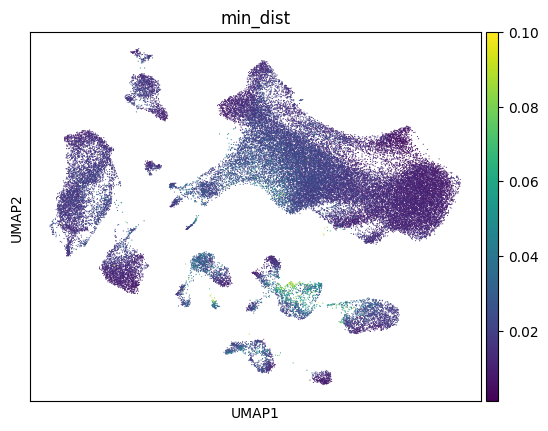

In [41]:
sc.pl.umap(adams, color="min_dist", vmax=0.1)